# Medical Appointment No-Show Prediction

**Dataset**: KaggleV2-May-2016.csv (~110,527 rows)

**Goal**: Predict no-show (`target = 1`)

Uses **native categorical support** in XGBoost → no manual encoding needed

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import xgboost as xgb

pd.set_option('display.max_columns', 50)
sns.set(style="whitegrid")
%matplotlib inline

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


## 1. Load the Data

In [44]:
df = pd.read_csv('KaggleV2-May-2016.csv', parse_dates=['ScheduledDay', 'AppointmentDay'])

print('Shape:', df.shape)
print('\nNo-show rate:')
print(df['No-show'].value_counts(normalize=True).round(4))

Shape: (110527, 14)

No-show rate:
No-show
No     0.7981
Yes    0.2019
Name: proportion, dtype: float64


## 2. Cleaning & Feature Engineering

In [45]:
df = df.rename(columns={
    'PatientId': 'patient_id', 'AppointmentID': 'appointment_id',
    'Gender': 'gender', 'ScheduledDay': 'scheduled_day',
    'AppointmentDay': 'appointment_day', 'Age': 'age',
    'Neighbourhood': 'neighbourhood', 'Scholarship': 'scholarship',
    'Hipertension': 'hypertension', 'Diabetes': 'diabetes',
    'Alcoholism': 'alcoholism', 'Handcap': 'handicap',
    'SMS_received': 'sms_received', 'No-show': 'no_show'
})

df['target'] = df['no_show'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['no_show'])

df['wait_days'] = (df['appointment_day'].dt.normalize() - df['scheduled_day'].dt.normalize()).dt.days
df['wait_days'] = df['wait_days'].clip(lower=0)

df['scheduled_hour'] = df['scheduled_day'].dt.hour
df['appointment_dow'] = df['appointment_day'].dt.day_name()
df['appointment_is_weekend'] = df['appointment_day'].dt.weekday >= 5
df['same_day'] = (df['wait_days'] == 0).astype(int)

df = df[(df['age'] >= 0) & (df['age'] <= 115)]
df['handicap_binary'] = (df['handicap'] > 0).astype(int)

print('Cleaned shape:', df.shape)

Cleaned shape: (110526, 20)


## 3. Patient History Features

In [46]:
df = df.sort_values(['patient_id', 'scheduled_day'])

df['prev_appointments'] = df.groupby('patient_id').cumcount()
df['cum_no_shows'] = df.groupby('patient_id')['target'].cumsum().shift(1).fillna(0)
df['prev_no_show_rate'] = np.where(
    df['prev_appointments'] > 0,
    df['cum_no_shows'] / df['prev_appointments'],
    0.0
)
df['days_since_last'] = df.groupby('patient_id')['appointment_day'].diff().dt.days.fillna(999)

In [47]:
# Group rare neighbourhoods (appears < 50 times) into 'Other'
rare_threshold = 50
neigh_counts = df['neighbourhood'].value_counts()
rare_mask = df['neighbourhood'].isin(neigh_counts[neigh_counts < rare_threshold].index)
df.loc[rare_mask, 'neighbourhood'] = 'Other_Rare'

print("Number of neighbourhoods after grouping:", df['neighbourhood'].nunique())

Number of neighbourhoods after grouping: 77


## 4. Train/Test Split

In [48]:
numeric_features = [
    'age', 'wait_days', 'scheduled_hour', 'scholarship', 'hypertension',
    'diabetes', 'alcoholism', 'handicap_binary', 'sms_received',
    'prev_no_show_rate', 'days_since_last', 'same_day', 'appointment_is_weekend'
]

cat_features = ['gender', 'appointment_dow', 'neighbourhood']

X = df[numeric_features + cat_features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=2025, stratify=y
)

## 5. Preprocessor + Model Pipeline

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), numeric_features),

        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('to_category', FunctionTransformer(lambda x: x.astype('category')))
        ]), cat_features)
    ],
    remainder='drop',
    verbose_feature_names_out=False
).set_output(transform="pandas")

model = xgb.XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    max_cat_threshold=255,

    n_estimators=1200,
    max_depth=6,
    learning_rate=0.035,
    subsample=0.82,
    colsample_bytree=0.78,
    eval_metric='aucpr',
    random_state=2025,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    early_stopping_rounds=80
)

pipe = Pipeline([('prep', preprocessor), ('xgb', model)])

# Safety check
print("enable_categorical:", pipe.named_steps['xgb'].enable_categorical)
print("tree_method:", pipe.named_steps['xgb'].tree_method)

enable_categorical: True
tree_method: hist


## 6. Training

In [50]:
import xgboost as xgb

# Transform (run this after preprocessor is defined)
X_train_tr = preprocessor.fit_transform(X_train)
X_test_tr  = preprocessor.transform(X_test)

print("Transformed train dtypes:\n", X_train_tr.dtypes)   # should show category

dtrain = xgb.DMatrix(
    X_train_tr, label=y_train,
    enable_categorical=True,
    feature_names=X_train_tr.columns.tolist()
)

deval = xgb.DMatrix(
    X_test_tr, label=y_test,
    enable_categorical=True,
    feature_names=X_train_tr.columns.tolist()
)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'max_cat_threshold': 255,
    'max_depth': 6,
    'learning_rate': 0.035,
    'subsample': 0.82,
    'colsample_bytree': 0.78,
    'scale_pos_weight': (y_train==0).sum() / (y_train==1).sum(),
    'random_state': 2025,
    'enable_categorical': True,
    'cat_missing_policy': 'encode_as_missing'   # ← FIX HERE
}

evals = [(dtrain, 'train'), (deval, 'eval')]

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=1200,
    evals=evals,
    early_stopping_rounds=80,
    verbose_eval=100
)

print("Training completed. Best iteration:", bst.best_iteration)

Transformed train dtypes:
 age                        float64
wait_days                  float64
scheduled_hour             float64
scholarship                float64
hypertension               float64
diabetes                   float64
alcoholism                 float64
handicap_binary            float64
sms_received               float64
prev_no_show_rate          float64
days_since_last            float64
same_day                   float64
appointment_is_weekend     float64
gender                    category
appointment_dow           category
neighbourhood             category
dtype: object
[0]	train-aucpr:0.39600	eval-aucpr:0.37614


/opt/anaconda3/envs/healthcare/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [10:11:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "cat_missing_policy", "enable_categorical" } are not used.

  self.starting_round = model.num_boosted_rounds()


[100]	train-aucpr:0.47072	eval-aucpr:0.42689
[200]	train-aucpr:0.50253	eval-aucpr:0.43347
[300]	train-aucpr:0.52932	eval-aucpr:0.43570
[400]	train-aucpr:0.55292	eval-aucpr:0.43592
[441]	train-aucpr:0.56169	eval-aucpr:0.43592
Training completed. Best iteration: 361


## 7. Evaluation

In [51]:
# Predictions using the trained Booster
bst.predict(deval)  # should work without error and return probabilities
proba = bst.predict(deval)          # probabilities for test set
pred  = (proba >= 0.5).astype(int)  # binary predictions (adjust threshold if needed)

print('ROC AUC :', round(roc_auc_score(y_test, proba), 4))
print('PR AUC  :', round(average_precision_score(y_test, proba), 4))
print('\nClassification Report:\n', classification_report(y_test, pred))

ROC AUC : 0.7625
PR AUC  : 0.436

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.62      0.74     17642
           1       0.34      0.76      0.47      4464

    accuracy                           0.65     22106
   macro avg       0.62      0.69      0.60     22106
weighted avg       0.80      0.65      0.68     22106



## 8. Feature Importance

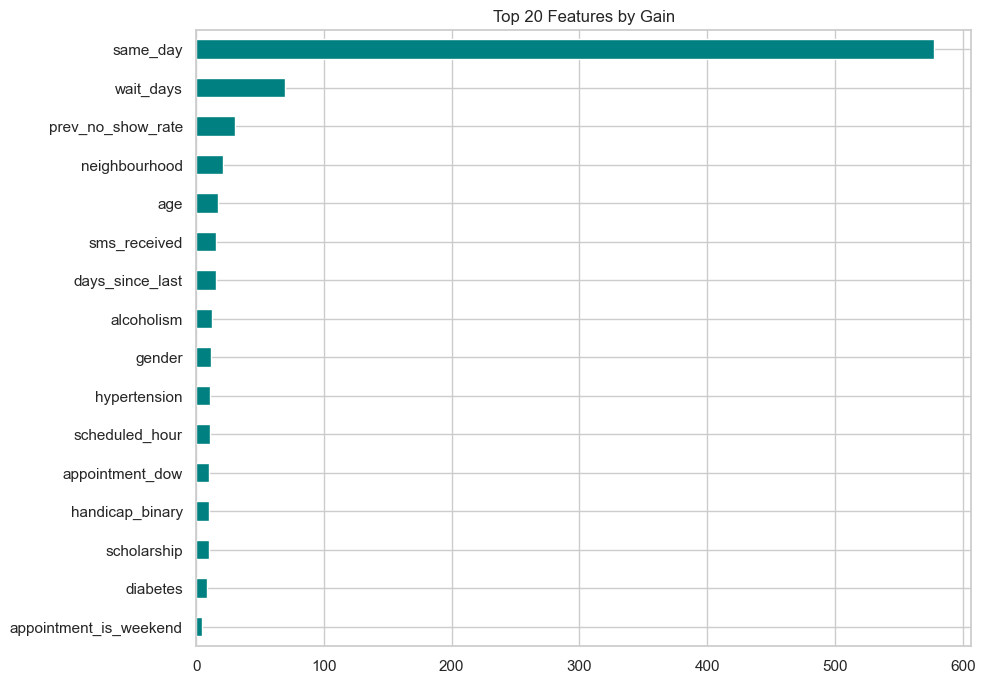

In [52]:
importances = pd.Series(
    bst.get_score(importance_type='gain'),   # or 'weight', 'cover'
    index=X_train_tr.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh', color='teal')
plt.title('Top 20 Features by Gain')
plt.gca().invert_yaxis()
plt.show()

## Done!

Next steps to consider:
- Try CatBoost or LightGBM (great with categoricals)
- Hyperparameter tuning (Optuna)
- GroupKFold by patient_id
- SHAP explanations